# 8. We will now perform cross-validation on a simulated data set.

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error

## (a) Generate a simulated data set as follows:
   $$\text{rng} = \text{np.random.default_rng}(1)$$

   $$x = \text{rng.normal}( \text{size}=100)$$
   
   $$y = x - 2x^2 + \text{rng.normal}( \text{size}=100)$$

## In this data set, what is n and what is p? Write out the model used to generate the data in equation form.

### Result
- $n \text{ 為樣本數 } = 100$
- $p \text{ 為預測變數（predictor）數量，這裡只有 x，因此 }p = 1。$

In [58]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

n = len(x)
n

100

## (b) Create a scatterplot of X against Y . Comment on what you find.

### Result

它的分布看起來像一個二次曲線函數。

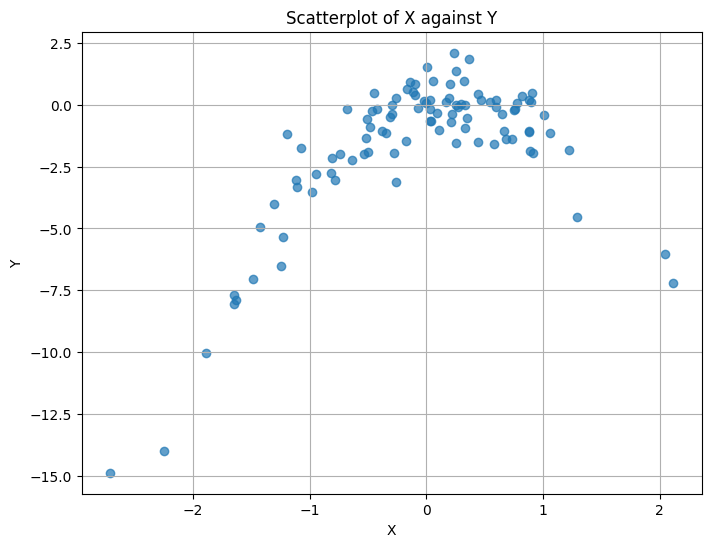

In [59]:
data = pd.DataFrame({'X': x, 'Y': y})

plt.figure(figsize=(8, 6))
plt.scatter(data['X'], data['Y'], alpha=0.7)
plt.title('Scatterplot of X against Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()

## (c) Set a random seed, and then compute the LOOCV errors that result from ftting the following four models using least squares:
$$ i. Y = β_0 + β_1X + ϵ$$
$$ ii. Y = β_0 + β_1X + β_2X^2 + ϵ$$
$$ iii. Y = β_0 + β_1X + β_2X^2 + β_3X^3 + ϵ$$
$$ iv. Y = β_0 + β_1X + β_2X^2 + β_3X^3 + β_4X^4 + ϵ$$


## Note you may fnd it helpful to use the data.frame() function to create a single data set containing both X and Y .


In [60]:
models = [
    'Y ~ X',
    'Y ~ X + I(X**2)',
    'Y ~ X + I(X**2) + I(X**3)',
    'Y ~ X + I(X**2) + I(X**3) + I(X**4)'
]

def calculate_loocv_mse(data, formula):
    loo = LeaveOneOut()
    mse_list = []

    for train_index, test_index in loo.split(data):
        train_data = data.iloc[train_index]
        test_data = data.iloc[test_index]

        model = smf.ols(formula=formula, data=train_data)
        results = model.fit()

        y_true = test_data['Y'].values[0]
        y_pred = results.predict(test_data).values[0]

        mse_list.append((y_true - y_pred)**2)

    return np.mean(mse_list)

In [61]:
np.random.seed(34)
loocv_errors = [calculate_loocv_mse(data, formula) for formula in models]

for i, error in enumerate(loocv_errors):
    print(f'Model {i+1} ({models[i]}): {error:.4f}')

Model 1 (Y ~ X): 6.6330
Model 2 (Y ~ X + I(X**2)): 1.1229
Model 3 (Y ~ X + I(X**2) + I(X**3)): 1.3018
Model 4 (Y ~ X + I(X**2) + I(X**3) + I(X**4)): 1.3324


## (d) Repeat (c) using another random seed, and report your results. Are your results the same as what you got in (c)? Why?

### Result
**一樣。**

因為 LOCCV 是一種非隨機的交叉驗證方法。

他執行 N 次，當 $N_i$ 為測試集，$\mathcal{N} \setminus \{N_i\} 為訓練集。$

In [62]:
np.random.seed(557)
loocv_errors_2 = [calculate_loocv_mse(data, formula) for formula in models]

for i, error in enumerate(loocv_errors_2):
    print(f'Model {i+1} ({models[i]}): {error:.4f}')

Model 1 (Y ~ X): 6.6330
Model 2 (Y ~ X + I(X**2)): 1.1229
Model 3 (Y ~ X + I(X**2) + I(X**3)): 1.3018
Model 4 (Y ~ X + I(X**2) + I(X**3) + I(X**4)): 1.3324


## (e) Which of the models in (c) had the smallest LOOCV error? Is this what you expected? Explain your answer.

### Result
最小的誤差是 1.229...，也就是 Model 2。
由於 Model 剛好是 $Y = β_0 + β_1X + β_2X^2 + ϵ$，跟原本的數據使用的公式 $Y = X - 2X^2 + \epsilon$ 同樣是二次方項，因此應該誤差最小。

- Model 1 -> 欠缺二次項擬合
- Model 3 -> 太多不必要的變異性
- Model 4 -> 太多不必要的變異性

In [63]:
min_error = min(loocv_errors)
best_model_index = loocv_errors.index(min_error)

print(min_error)

1.1229368563419686


## (f) Comment on the statistical signifcance of the coefcient estimates that results from ftting each of the models in (c) using least squares. Do these results agree with the conclusions drawn based on the cross-validation results?

### Result
從結果可以看出，三階項的 X 的 p-value 特別大（> 0.05），代表其對模型不顯著。


In [64]:
for i, formula in enumerate(models):
    print(f'\nModel {i+1}: {formula}')

    model = smf.ols(formula=formula, data=data)
    results = model.fit()

    print(results.summary().tables[1])

    sig_vars = results.pvalues[results.pvalues < 0.05]
    print(f'(p < 0.05): {list(sig_vars.index)}')


Model 1: Y ~ X
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.4650      0.247     -5.937      0.000      -1.955      -0.975
X              1.9494      0.289      6.752      0.000       1.376       2.522
(p < 0.05): ['Intercept', 'X']

Model 2: Y ~ X + I(X**2)
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0728      0.119     -0.611      0.543      -0.309       0.164
X              0.9663      0.126      7.647      0.000       0.715       1.217
I(X ** 2)     -2.0047      0.091    -22.072      0.000      -2.185      -1.824
(p < 0.05): ['X', 'I(X ** 2)']

Model 3: Y ~ X + I(X**2) + I(X**3)
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------